In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\srujan  R\OneDrive\Desktop\truthtrace-llm\data\processed\dataset_ready_for_training.csv")

In [6]:
df.head()

,title,text,subject,label,text_len,title_len,combined_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,0,2893,79,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,0,1898,69,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,0,3597,90,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,0,2774,78,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,0,2346,70,Pope Francis Just Called Out Donald Trump Dur...


In [9]:
X = df['combined_text']
y = df['label']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test_tfidf)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9879732739420936

 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4733
           1       0.98      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



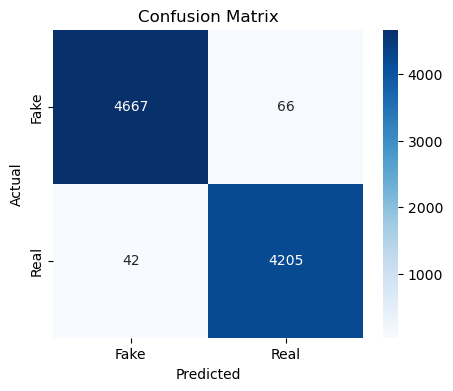

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

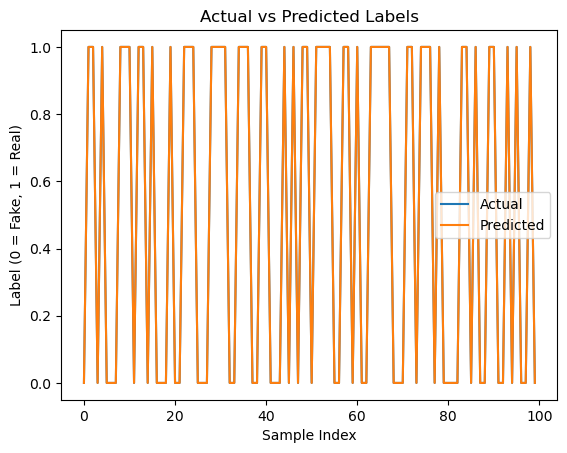

In [33]:
import matplotlib.pyplot as plt

# Just plot the first 100 samples for simplicity
plt.plot(y_test[:100].values, label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Actual vs Predicted Labels')
plt.xlabel('Sample Index')
plt.ylabel('Label (0 = Fake, 1 = Real)')
plt.legend()
plt.show()


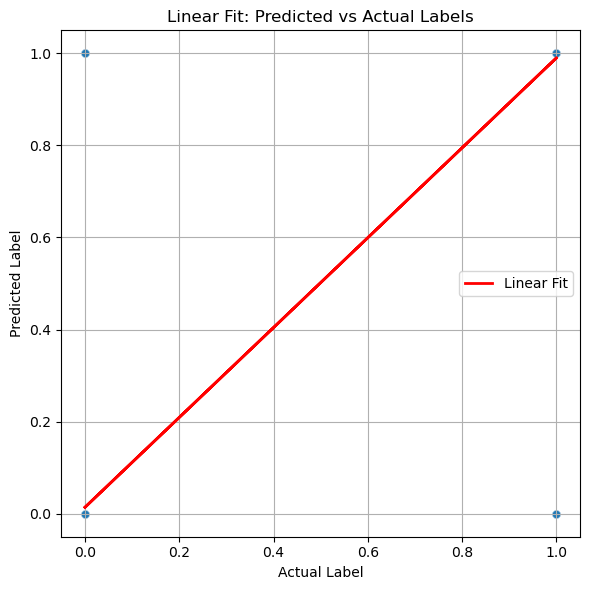

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Convert to NumPy arrays
y_test_np = y_test.to_numpy().reshape(-1, 1)
y_pred_np = y_pred.reshape(-1, 1)

# Fit linear regression line
lr = LinearRegression()
lr.fit(y_test_np, y_pred_np)
y_line = lr.predict(y_test_np)

# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_np.flatten(), y=y_pred_np.flatten(), alpha=0.3)
plt.plot(y_test_np, y_line, color='red', linewidth=2, label='Linear Fit')
plt.title("Linear Fit: Predicted vs Actual Labels")
plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [37]:
"""
“My baseline model using TF-IDF + Logistic Regression achieved 98.8% accuracy with excellent alignment between predicted and actual labels. From there, I built on top using LLMs and causal modeling for deeper insights
"""

'\n“My baseline model using TF-IDF + Logistic Regression achieved 98.8% accuracy with excellent alignment between predicted and actual labels. From there, I built on top using LLMs and causal modeling for deeper insights\n'